# Central Limit Theorem

If we repeatedly take random samples from a population and calculate their means, the distribution of those sample means will become approximately normal as the sample size becomes large enough — even if the original population is not normally distributed.  

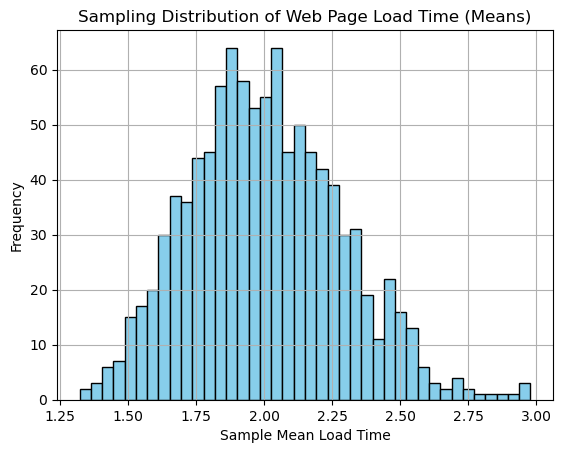

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Simulate skewed load time data 
np.random.seed(0)
population = np.random.exponential(scale=2.0, size=100000)

# Parameters
sample_size = 50
num_samples = 1000
sample_means = []

# Take samples and compute means
for _ in range(num_samples):
    sample = np.random.choice(population, size=sample_size)
    sample_means.append(np.mean(sample))

# Plot the sample means
plt.hist(sample_means, bins=40, color='skyblue', edgecolor='black')
plt.title('Sampling Distribution of Web Page Load Time (Means)')
plt.xlabel('Sample Mean Load Time')
plt.ylabel('Frequency')
plt.grid(True)
plt.show()


## Practical Applications of the CLT

### 1️⃣ Model Evaluation and Confidence Intervals:

CLT helps build confidence intervals around model predictions, showing how reliable they are more data leads to tighter intervals and more trust in results.

As the sample size increases, the confidence interval becomes narrower. This happens because the CLT reduces the standard error, making model predictions more stable and reliable.

Small Sample (n=30)
Mean Prediction: 48.12
95% Confidence Interval: (44.76, 51.48)

Large Sample (n=1000)
Mean Prediction: 50.38
95% Confidence Interval: (49.77, 50.98)


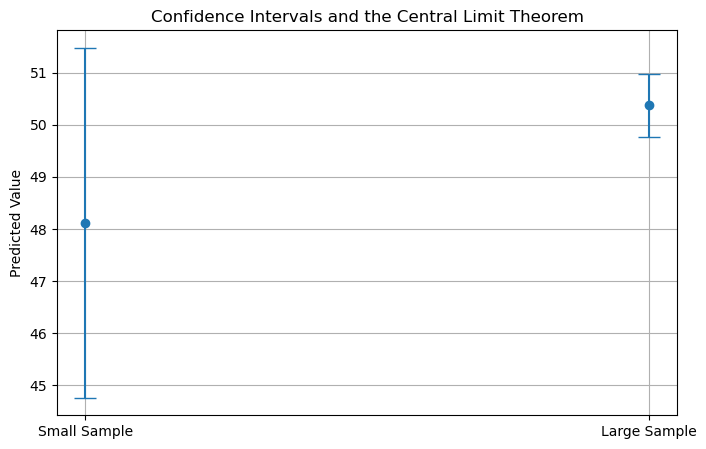

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

# Simulated model prediction errors
np.random.seed(42)

# Small dataset
small_sample = np.random.normal(loc=50, scale=10, size=30)

# Large dataset
large_sample = np.random.normal(loc=50, scale=10, size=1000)

# Function to calculate confidence interval
def confidence_interval(data, confidence=0.95):
    mean = np.mean(data)
    sem = stats.sem(data)  # Standard Error of Mean
    margin = sem * stats.t.ppf((1 + confidence) / 2, len(data)-1)
    return mean, mean - margin, mean + margin

# Calculate intervals
small_mean, small_lower, small_upper = confidence_interval(small_sample)
large_mean, large_lower, large_upper = confidence_interval(large_sample)

# Print results
print("Small Sample (n=30)")
print(f"Mean Prediction: {small_mean:.2f}")
print(f"95% Confidence Interval: ({small_lower:.2f}, {small_upper:.2f})\n")

print("Large Sample (n=1000)")
print(f"Mean Prediction: {large_mean:.2f}")
print(f"95% Confidence Interval: ({large_lower:.2f}, {large_upper:.2f})")

# Visualization
plt.figure(figsize=(8, 5))

plt.errorbar(
    x=["Small Sample", "Large Sample"],
    y=[small_mean, large_mean],
    yerr=[
        [small_mean - small_lower, large_mean - large_lower],
        [small_upper - small_mean, large_upper - large_mean]
    ],
    fmt='o',
    capsize=8
)

plt.ylabel("Predicted Value")
plt.title("Confidence Intervals and the Central Limit Theorem")
plt.grid(True)

plt.show()

### 2️⃣ A/B Testing: 

A/B Testing is used in product development, CLT ensures that average outcomes from repeated experiments become normally distributed, even with skewed data.

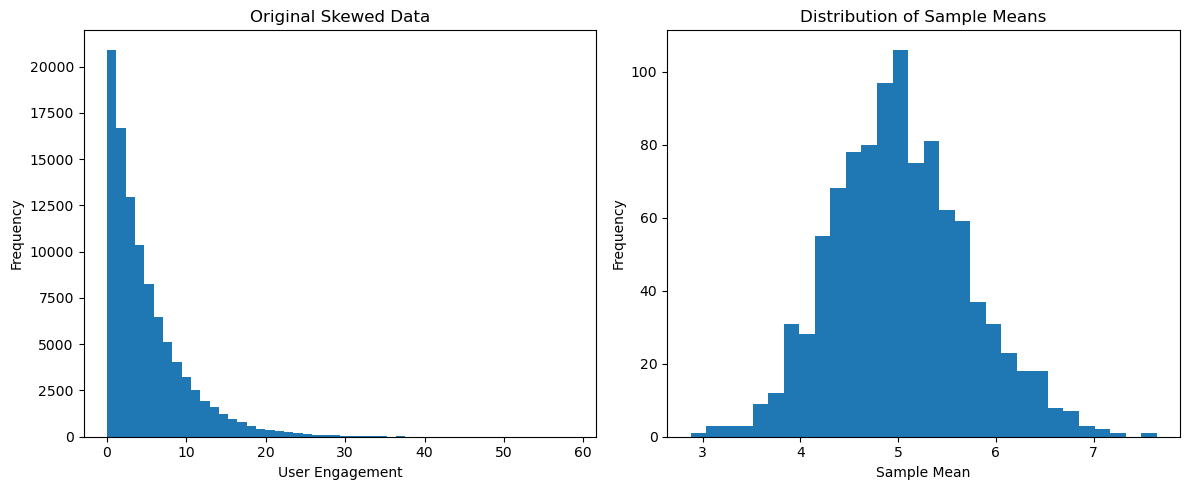

Population Mean: 4.98
Mean of Sample Means: 5.03
Standard Deviation of Sample Means: 0.70


In [3]:
import numpy as np
import matplotlib.pyplot as plt

# Reproducibility
np.random.seed(42)

# Simulate skewed user behavior data
# Example: time spent on a website (exponential distribution)
population = np.random.exponential(scale=5, size=100000)

# A/B testing simulation
sample_size = 50
num_experiments = 1000

sample_means = []

# Repeated experiments
for _ in range(num_experiments):
    sample = np.random.choice(population, size=sample_size)
    sample_means.append(np.mean(sample))

# Plot original skewed population
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.hist(population, bins=50)
plt.title("Original Skewed Data")
plt.xlabel("User Engagement")
plt.ylabel("Frequency")

# Plot distribution of sample means
plt.subplot(1, 2, 2)
plt.hist(sample_means, bins=30)
plt.title("Distribution of Sample Means")
plt.xlabel("Sample Mean")
plt.ylabel("Frequency")

plt.tight_layout()
plt.show()

# Print statistics
print(f"Population Mean: {np.mean(population):.2f}")
print(f"Mean of Sample Means: {np.mean(sample_means):.2f}")
print(f"Standard Deviation of Sample Means: {np.std(sample_means):.2f}")

In A/B testing, user behaviour data is often highly skewed. However, thanks to the CLT, the distribution of sample means becomes approximately normal when experiments are repeated many times. This allows data scientists to use statistical tests and confidence intervals reliably, even when the original data is not normally distributed.

### 3️⃣ Error and Uncertainty Estimation:

CLT allows us to estimate prediction errors and standard errors, helping assess model uncertainty on new data.

 Error and Uncertainty Estimation 
Mean Prediction Error      : 0.57
Standard Deviation of Error: 7.98
Standard Error             : 0.2523
95% Confidence Interval    : (0.07, 1.06)


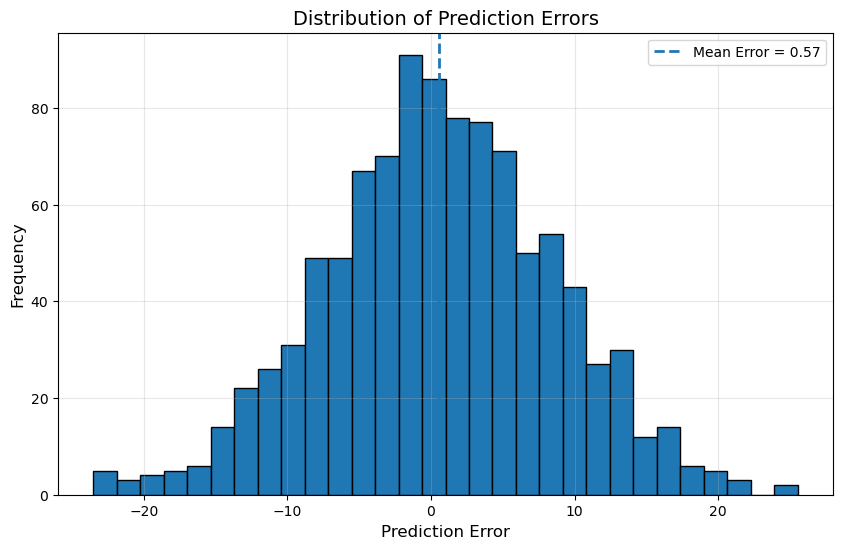

In [5]:
# ==========================================
# Error & Uncertainty Estimation using CLT
# ==========================================

import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

# ------------------------------------------
# 1. Generate Simulated Data
# ------------------------------------------

np.random.seed(42)

# True target values
true_values = np.random.normal(
    loc=100,
    scale=15,
    size=1000
)

# Model predictions with random noise
predictions = true_values + np.random.normal(
    loc=0,
    scale=8,
    size=1000
)

# ------------------------------------------
# 2. Calculate Prediction Errors
# ------------------------------------------

errors = predictions - true_values

mean_error = np.mean(errors)
std_error = np.std(errors, ddof=1)

# Standard Error from CLT
standard_error = std_error / np.sqrt(len(errors))

# ------------------------------------------
# 3. Compute 95% Confidence Interval
# ------------------------------------------

confidence_level = 0.95

margin_of_error = (
    stats.t.ppf(
        (1 + confidence_level) / 2,
        len(errors) - 1
    ) * standard_error
)

lower_bound = mean_error - margin_of_error
upper_bound = mean_error + margin_of_error

# ------------------------------------------
# 4. Print Results
# ------------------------------------------

print("=" * 50)
print(" Error and Uncertainty Estimation ")
print("=" * 50)

print(f"Mean Prediction Error      : {mean_error:.2f}")
print(f"Standard Deviation of Error: {std_error:.2f}")
print(f"Standard Error             : {standard_error:.4f}")

print(
    f"95% Confidence Interval    : "
    f"({lower_bound:.2f}, {upper_bound:.2f})"
)

# ------------------------------------------
# 5. Visualization
# ------------------------------------------

plt.figure(figsize=(10, 6))

plt.hist(
    errors,
    bins=30,
    edgecolor='black'
)

plt.axvline(
    mean_error,
    linestyle='dashed',
    linewidth=2,
    label=f"Mean Error = {mean_error:.2f}"
)

plt.title(
    "Distribution of Prediction Errors",
    fontsize=14
)

plt.xlabel("Prediction Error", fontsize=12)
plt.ylabel("Frequency", fontsize=12)

plt.legend()
plt.grid(alpha=0.3)

plt.show()

The CLT allows us to estimate the distribution of prediction errors and calculate standard errors. As the sample size increases, the estimate of the model's average error becomes more stable, helping data scientists quantify uncertainty and evaluate how reliable predictions are on unseen data.

### 4️⃣ Bootstrapping:

By resampling data, CLT supports reliable estimation of metrics like MSE and confidence intervals for model parameters.

 Bootstrapping + CLT (MSE Estimation) 
Mean Bootstrap MSE : 24.2803
Std of MSE         : 2.8225
Standard Error     : 0.089255
95% CI (CLT approx): (24.1054, 24.4553)


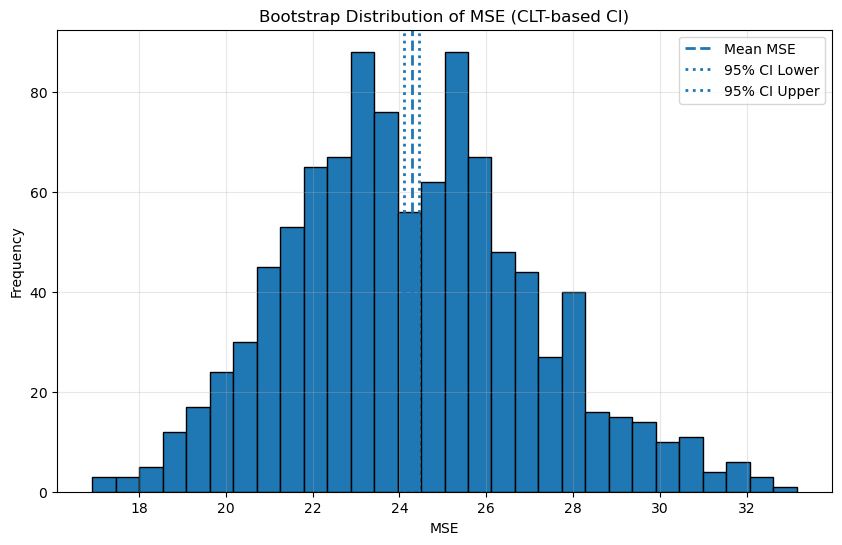

In [6]:
# ==========================================
# Bootstrapping + CLT for Model Evaluation
# MSE + Confidence Intervals
# ==========================================

import numpy as np
import matplotlib.pyplot as plt

from sklearn.metrics import mean_squared_error

# ------------------------------------------
# 1. Simulate Data
# ------------------------------------------

np.random.seed(42)

n = 200

# True values (ground truth)
y_true = np.random.normal(loc=50, scale=10, size=n)

# Model predictions (with noise)
y_pred = y_true + np.random.normal(loc=0, scale=5, size=n)

# ------------------------------------------
# 2. Bootstrapping
# ------------------------------------------

n_bootstrap = 1000
bootstrap_mse = []

for _ in range(n_bootstrap):

    # resample indices with replacement
    idx = np.random.choice(n, size=n, replace=True)

    sample_true = y_true[idx]
    sample_pred = y_pred[idx]

    # compute metric (MSE)
    mse = mean_squared_error(sample_true, sample_pred)
    bootstrap_mse.append(mse)

bootstrap_mse = np.array(bootstrap_mse)

# ------------------------------------------
# 3. Statistics (CLT idea)
# ------------------------------------------

mean_mse = np.mean(bootstrap_mse)
std_mse = np.std(bootstrap_mse, ddof=1)

# standard error of bootstrap distribution
se_mse = std_mse / np.sqrt(n_bootstrap)

# 95% confidence interval (normal approx from CLT)
z = 1.96
ci_lower = mean_mse - z * se_mse
ci_upper = mean_mse + z * se_mse

# ------------------------------------------
# 4. Print Results
# ------------------------------------------

print("=" * 55)
print(" Bootstrapping + CLT (MSE Estimation) ")
print("=" * 55)

print(f"Mean Bootstrap MSE : {mean_mse:.4f}")
print(f"Std of MSE         : {std_mse:.4f}")
print(f"Standard Error     : {se_mse:.6f}")

print(f"95% CI (CLT approx): ({ci_lower:.4f}, {ci_upper:.4f})")

# ------------------------------------------
# 5. Visualization
# ------------------------------------------

plt.figure(figsize=(10, 6))

plt.hist(bootstrap_mse, bins=30, edgecolor="black")

plt.axvline(mean_mse, linestyle="dashed", linewidth=2, label="Mean MSE")

plt.axvline(ci_lower, linestyle="dotted", linewidth=2, label="95% CI Lower")
plt.axvline(ci_upper, linestyle="dotted", linewidth=2, label="95% CI Upper")

plt.title("Bootstrap Distribution of MSE (CLT-based CI)")
plt.xlabel("MSE")
plt.ylabel("Frequency")
plt.legend()
plt.grid(alpha=0.3)

plt.show()

### 5️⃣ Feature Importance:

CLT helps check if feature rankings remain stable across samples, ensuring the most consistent and reliable features are chosen.

 Feature Importance Stability (Bootstrap + CLT) 
Feature  Mean Importance  Std Dev  Std Error
     X3        81.987471 0.528591   0.016716
     X2        50.391256 0.557132   0.017618
     X4        26.737898 0.624544   0.019750
     X0         8.111349 0.603246   0.019076
     X1         5.545406 0.626649   0.019816


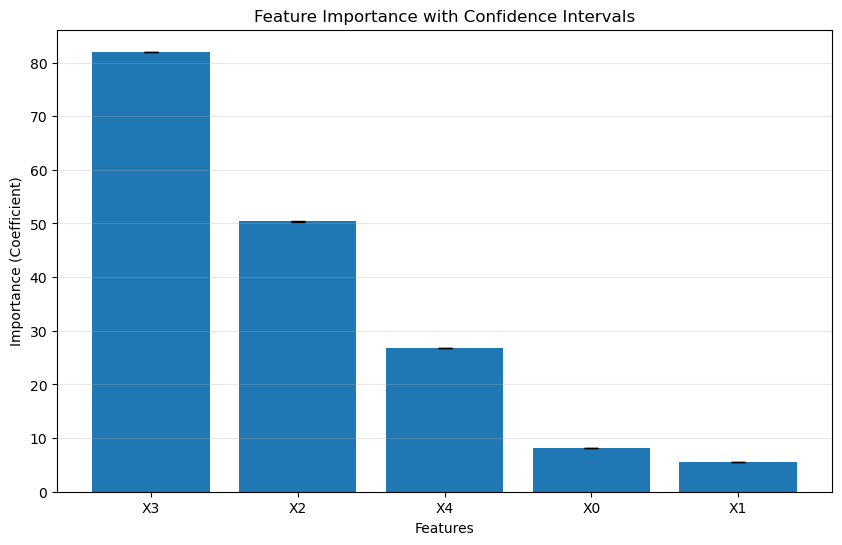

In [8]:
# ==========================================
# Feature Importance Stability using Bootstrapping (CLT intuition)
# ==========================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import make_regression
from sklearn.linear_model import LinearRegression

# ------------------------------------------
# 1. Generate Synthetic Dataset
# ------------------------------------------

np.random.seed(42)

X, y = make_regression(
    n_samples=300,
    n_features=5,
    noise=10,
    random_state=42
)

feature_names = [f"X{i}" for i in range(X.shape[1])]

# ------------------------------------------
# 2. Bootstrap Feature Importance
# ------------------------------------------

n_bootstrap = 1000
coefs = np.zeros((n_bootstrap, X.shape[1]))

model = LinearRegression()

for i in range(n_bootstrap):

    # resample data (bootstrap sample)
    idx = np.random.choice(len(X), size=len(X), replace=True)

    X_sample = X[idx]
    y_sample = y[idx]

    model.fit(X_sample, y_sample)

    coefs[i] = model.coef_

# ------------------------------------------
# 3. Analyze Stability (CLT intuition)
# ------------------------------------------

coef_mean = np.mean(coefs, axis=0)
coef_std = np.std(coefs, axis=0, ddof=1)

# Standard error of coefficients
coef_se = coef_std / np.sqrt(n_bootstrap)

# Create summary table
results = pd.DataFrame({
    "Feature": feature_names,
    "Mean Importance": coef_mean,
    "Std Dev": coef_std,
    "Std Error": coef_se
})

results = results.sort_values(by="Mean Importance", key=np.abs, ascending=False)

# ------------------------------------------
# 4. Print Results
# ------------------------------------------

print("=" * 60)
print(" Feature Importance Stability (Bootstrap + CLT) ")
print("=" * 60)
print(results.to_string(index=False))

# ------------------------------------------
# 5. Visualization
# ------------------------------------------

plt.figure(figsize=(10, 6))

plt.bar(
    results["Feature"],
    results["Mean Importance"],
    yerr=1.96 * results["Std Error"],
    capsize=5
)

plt.title("Feature Importance with Confidence Intervals")
plt.xlabel("Features")
plt.ylabel("Importance (Coefficient)")
plt.grid(axis="y", alpha=0.3)

plt.show()